In [3]:
library(vcd)
library(lsr)
library(dplyr)
library(ggplot2)
library(tidyr)
library(stringr)
library(tidyverse)
library(DESeq2)
library(survival)
library(survminer)
library(broom)
library(edgeR)

In [ ]:
meta<-read.delim("../1_DATA/sample_meta_passQC.tsv")
samples<-read.delim("../1_DATA/metrics_passQC.tsv")
# %>%filter(ORIGIN=="MCC")

# Inner join: keep only overlapping Record_IDs
# meta_overlap <- merge(meta, samples, by = "sample_id", all = FALSE)
meta_overlap2<-read.delim("../dfc_clinical.tsv")
counts<-read.delim("../counts_sQC_gAll_nRaw.tsv")
# meta_overlap2<- read_excel("/workdir/gfa32/hsct_new/PAPER2_cfrna/data/Baseline_data_clean.xlsx")

exempt <- merge(meta, meta_overlap2, by = "Record_ID", all = FALSE)

In [23]:
head(clin_vars)

,Record_ID,hct_source,hct_hla,conditioning_regimen,hct_donor,cmv_serostatus,baseline_disease,age,sex
,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<fct>
1,100,Bone marrow,Matched,RIC,Unrelated,D+/R-,Lymphoma,52,Female
2,100,Bone marrow,Matched,RIC,Unrelated,D+/R-,Lymphoma,52,Female
3,100,Bone marrow,Matched,RIC,Unrelated,D+/R-,Lymphoma,52,Female
4,100,Bone marrow,Matched,RIC,Unrelated,D+/R-,Lymphoma,52,Female
5,100,Bone marrow,Matched,RIC,Unrelated,D+/R-,Lymphoma,52,Female
6,101,Peripheral blood,Haploidentical,Myeloablative,Related,D+/R+,Acute leukemia,21,Female


=== UNIVARIATE ===
# A tibble: 22 × 6
   covariate            term                 estimate conf.low conf.high p.value
   <chr>                <chr>                   <dbl>    <dbl>     <dbl>   <dbl>
 1 cfRNA_score          cfRNA_score              1.73     1.09      2.72   0.019
 2 hct_source           hct_sourcePeriphera…     0.74     0.34      1.59   0.437
 3 hct_source           hct_sourceUmbilical…     1.26     0.33      4.77   0.731
 4 hct_hla              hct_hlaMatched           1.16     0.6       2.25   0.663
 5 hct_hla              hct_hlaMismatched        0.39     0.15      1.05   0.063
 6 conditioning_regimen conditioning_regime…     0.65     0.28      1.54   0.331
 7 hct_donor            hct_donorUnrelated       0.8      0.44      1.47   0.478
 8 cmv_serostatus       cmv_serostatusD-/R+      1.74     0.83      3.66   0.143
 9 cmv_serostatus       cmv_serostatusD+/R-      0.92     0.44      1.94   0.837
10 cmv_serostatus       cmv_serostatusD+/R+      0.98     0.41      2.3

`height` was translated to `width`.


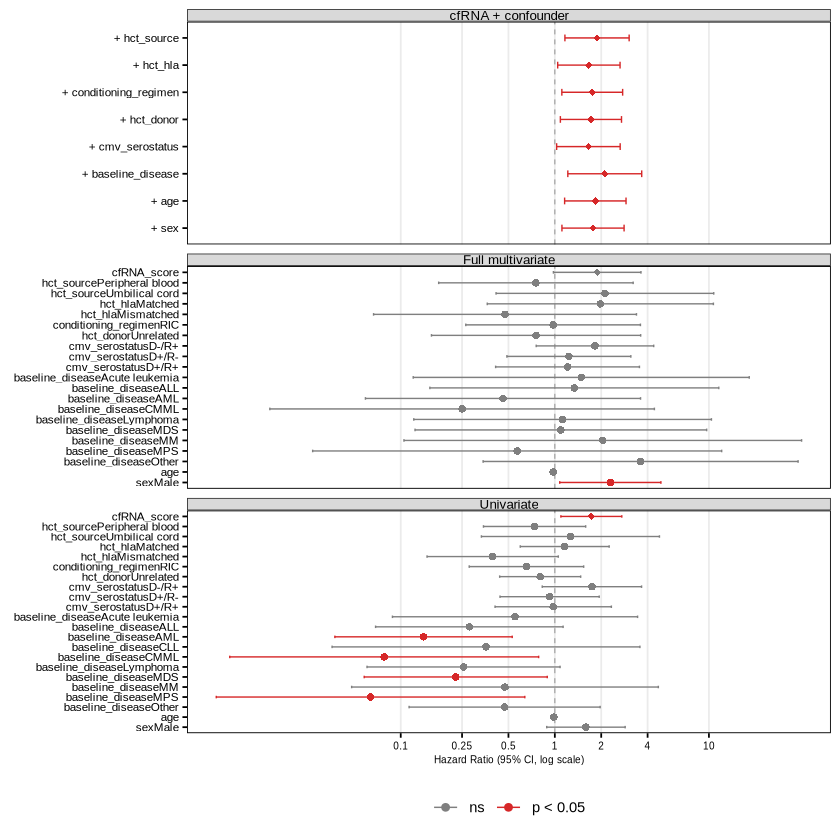

In [ ]:

source("/theme_ggplot_cfrna.R")
gene_key <- read.delim("/gencode.biotype.name.key.tsv")

## ---- 1. Compute cfRNA score ----
GENEIDS <- gene_key %>% filter(gene_name %in% c("CCL21","RHD")) %>% pull(gene_id)
CNTS    <- edgeR::cpm(counts)

score_df <- data.frame(t(CNTS[GENEIDS, , drop=FALSE])) %>%
    rownames_to_column("sample_id")
colnames(score_df)[-1] <- gene_key$gene_name[match(GENEIDS, gene_key$gene_id)]
score_df <- score_df %>%
    mutate(cfRNA_score = log10((CCL21 + 1) / (RHD + 1)))

## ---- 2. One sample per patient (earliest pre-GVHD timepoint from EVENTS) ----
# EVENTS <- c("taper_start","taper_end","post_taper")
EVENTS <- c("3M","6M")
slice <- dplyr::slice

cox_samples <- exempt %>%
    mutate(expGroup = ifelse(is.na(date_Lgvhd),"GVHD-","GVHD+")) %>%
    filter(rel_Lgvhd < 0 | is.na(date_Lgvhd)) %>%       # pre-GVHD only
    filter(timepoint %in% EVENTS) %>%
    left_join(score_df %>% select(sample_id, cfRNA_score), by="sample_id") %>%
    filter(!is.na(cfRNA_score)) %>%
    group_by(Record_ID) %>%
    arrange(match(timepoint, EVENTS)) %>%
    slice(1) %>%
    ungroup() %>%
    mutate(
        event = as.integer(!is.na(date_Lgvhd)),
        time  = ifelse(is.na(rel_Lgvhd),
                       max(-rel_Lgvhd, na.rm=TRUE) + 100,
                       -rel_Lgvhd)
    ) %>%
    filter(time > 0)


clin_vars <- exempt %>%
    group_by(Record_ID) %>%
    slice(1) %>%
    ungroup() %>%
    select(
        Record_ID,
        hct_source,
        hct_hla,
        conditioning_regimen,
        hct_donor,
        cmv_serostatus,
        baseline_disease,
        age,
        sex
    )
##For MCC cohort
# clin_vars <- exempt %>%
#     group_by(Record_ID) %>%
#     slice(1) %>%
#     ungroup() %>%
#     select(
#         Record_ID,
#         HLA_match,
#         donor_type,
#         conditioning,
#         graft,
#         Prior_CMV_reactivation,
#         disease,
#         age,
#         gender
#     )

cox_df <- cox_samples %>%
    select(Record_ID, sample_id, event, time, cfRNA_score) %>%  # keep only needed cols
    left_join(clin_vars, by = "Record_ID") %>%
    filter(!is.na(time))

## ---- 4. Univariate Cox ----
COVARIATES <- c("cfRNA_score","hct_source","hct_hla","conditioning_regimen",
                "hct_donor","cmv_serostatus","baseline_disease","age","sex")

univ_results <- lapply(COVARIATES, function(var) {
    f <- as.formula(paste0("Surv(time, event) ~ ", var))
    fit <- tryCatch(coxph(f, data=cox_df), error=function(e) NULL)
    if (is.null(fit)) return(NULL)
    tidy(fit, exponentiate=TRUE, conf.int=TRUE) %>%
        mutate(covariate=var, panel="Univariate")
}) %>% bind_rows()

# ## ---- 5. Pairwise multivariate: cfRNA + each confounder ----
CONFOUNDERS <- setdiff(COVARIATES, "cfRNA_score")


pair_results <- lapply(CONFOUNDERS, function(var) {
    f   <- as.formula(paste0("Surv(time, event) ~ cfRNA_score + ", var))
    fit <- tryCatch(coxph(f, data=cox_df),
                    error   = function(e) { cat("ERROR [", var, "]:", conditionMessage(e), "\n"); NULL },
                    warning = function(w) { cat("WARN  [", var, "]:", conditionMessage(w), "\n");
                                            suppressWarnings(coxph(f, data=cox_df)) })
    if (is.null(fit)) return(NULL)
    tidy(fit, exponentiate=TRUE, conf.int=TRUE) %>%
        filter(term=="cfRNA_score") %>%
        mutate(covariate=paste0("+ ", var), panel="cfRNA + confounder")
}) %>% bind_rows()



full_f   <- as.formula(paste0("Surv(time,event) ~ ", paste(COVARIATES, collapse="+")))
full_fit <- tryCatch(coxph(full_f, data=cox_df), error=function(e) NULL)

full_results <- if (!is.null(full_fit)) {
    tidy(full_fit, exponentiate=TRUE, conf.int=TRUE) %>%
        mutate(covariate=term, panel="Full multivariate")
} else data.frame()


cat("=== UNIVARIATE ===\n")
univ_results %>%
    select(covariate, term, estimate, conf.low, conf.high, p.value) %>%
    mutate(across(c(estimate,conf.low,conf.high), ~round(.,2)),
           p.value=round(p.value,3)) %>% print(n=50)

cat("\n=== PAIRWISE (cfRNA term only) ===\n")
pair_results %>%
    select(covariate, estimate, conf.low, conf.high, p.value) %>%
    mutate(across(c(estimate,conf.low,conf.high), ~round(.,2)),
           p.value=round(p.value,3)) %>% print(n=50)


# # cfRNA rows across all three panels
forest_df <- bind_rows(
    univ_results %>%
        mutate(label=term),
    pair_results %>%
        mutate(label=covariate),
    full_results %>%
        mutate(label=term)
) %>%
    filter(!is.na(estimate), !is.na(conf.low), !is.na(conf.high)) %>%
    filter(conf.high < 50) %>%                        # drop extreme/unstable estimates
    mutate(
        sig   = ifelse(p.value < 0.05,"p < 0.05","ns"),
        is_cfrna = grepl("cfRNA", term),
        label = factor(label, levels=rev(unique(label)))
    )

forest_plt <- forest_df %>%
    ggplot(aes(y=label, x=estimate, xmin=conf.low, xmax=conf.high,
               color=sig, shape=is_cfrna)) +
    geom_vline(xintercept=1, linetype="dashed", color="gray60", linewidth=0.3) +
    geom_errorbarh(height=0.25, linewidth=0.4) +
    geom_point(size=1.8) +
    scale_color_manual(values=c("p < 0.05"="#d62728","ns"="gray50")) +
    scale_shape_manual(values=c("TRUE"=18,"FALSE"=16), guide="none") +
    scale_x_log10(breaks=c(0.1,0.25,0.5,1,2,4,10),
                  labels=c("0.1","0.25","0.5","1","2","4","10")) +
    facet_wrap(~panel, scales="free_y", ncol=1) +
    labs(x="Hazard Ratio (95% CI, log scale)", y=NULL, color=NULL) +
    theme_cfrna_print() +
    theme(
        panel.grid.minor  = element_blank(),
        panel.grid.major.y = element_blank(),
        strip.text        = element_text(size=8),
        legend.position   = "bottom",
        axis.text.y       = element_text(size=7)
    )

forest_plt



cfRNA HR adjusted for each confounder individually:
# A tibble: 8 × 5
  confounder           estimate conf.low conf.high p.value
  <chr>                   <dbl>    <dbl>     <dbl>   <dbl>
1 hct_source               1.88     1.16      3.04  0.01  
2 hct_hla                  1.66     1.04      2.65  0.0324
3 conditioning_regimen     1.75     1.11      2.76  0.0159
4 hct_donor                1.72     1.09      2.71  0.0206
5 cmv_serostatus           1.65     1.03      2.66  0.0383
6 baseline_disease         2.11     1.21      3.66  0.0081
7 age                      1.83     1.16      2.90  0.0097
8 sex                      1.77     1.11      2.82  0.016 


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
`height` was translated to `width`.
`height` was translated to `width`.


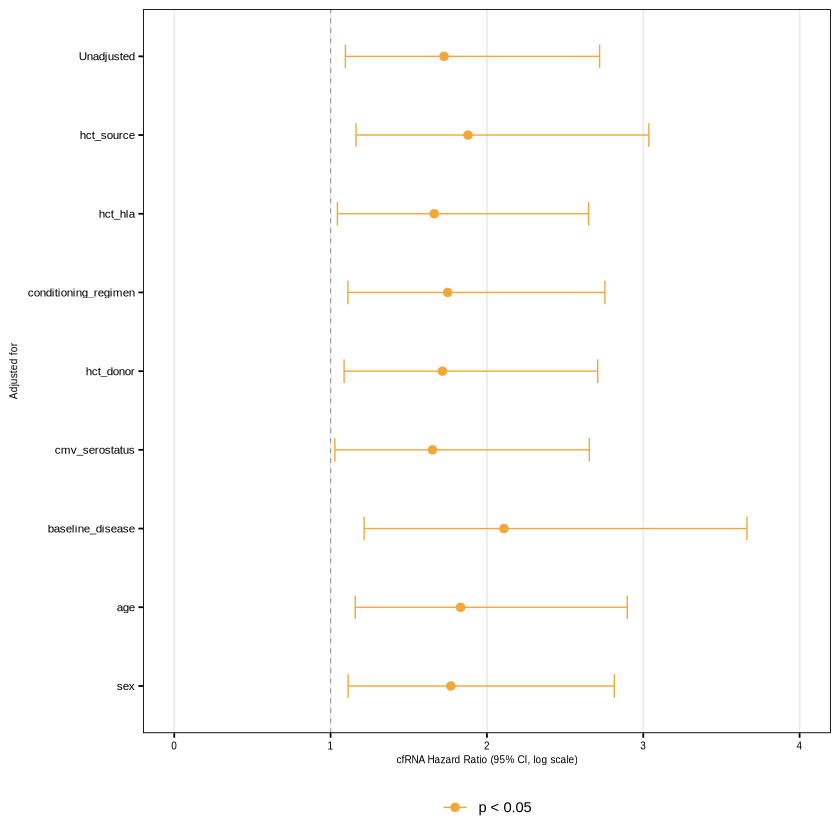

In [ ]:
## ---- cfRNA HR adjusted for each confounder individually ----

pair_results <- lapply(CONFOUNDERS, function(var) {
    f   <- as.formula(paste0("Surv(time, event) ~ cfRNA_score + ", var))
    fit <- tryCatch(coxph(f, data=cox_df),
                    error   = function(e) { cat("ERROR [", var, "]:", conditionMessage(e), "\n"); NULL },
                    warning = function(w) suppressWarnings(coxph(f, data=cox_df)))
    if (is.null(fit)) return(NULL)
    tidy(fit, exponentiate=TRUE, conf.int=TRUE) %>%
        filter(term=="cfRNA_score") %>%
        mutate(confounder=var)
}) %>% bind_rows()

## Print
cat("cfRNA HR adjusted for each confounder individually:\n")
pair_results %>%
    select(confounder, estimate, conf.low, conf.high, p.value) %>%
    mutate(across(c(estimate,conf.low,conf.high), ~round(.,3)),
           p.value=round(p.value,4)) %>%
    print(n=20)

## Add unadjusted row for reference
univ_cfrna <- tidy(coxph(Surv(time,event) ~ cfRNA_score, data=cox_df),
                   exponentiate=TRUE, conf.int=TRUE) %>%
    mutate(confounder="Unadjusted")

plot_df <- bind_rows(univ_cfrna, pair_results) %>%
    mutate(
        confounder = factor(confounder,
                            levels=rev(c("Unadjusted", CONFOUNDERS))),
        sig        = ifelse(p.value < 0.05,"p < 0.05","ns")
    )

pair_plt <- plot_df %>%
    ggplot(aes(y=confounder, x=estimate, xmin=conf.low, xmax=conf.high, color=sig)) +
    geom_vline(xintercept=1, linetype="dashed", color="gray60", linewidth=0.3) +
    geom_errorbarh(height=0.3, linewidth=0.4) +
    geom_point(size=2) +
    scale_color_manual(values=c("p < 0.05"="#f2a73b","ns"="gray50")) +
    scale_x_log10(breaks=c(0.25,0.5,1,2,4),
                  labels=c("0.25","0.5","1","2","4")) +
    labs(x="cfRNA Hazard Ratio (95% CI, log scale)",
         y="Adjusted for",
         color=NULL) +
         xlim(0,4)+
    theme_cfrna_print() +
    theme(panel.grid.minor   = element_blank(),
          panel.grid.major.y = element_blank(),
          axis.text.y        = element_text(size=7),
          legend.position    = "bottom")

pair_plt
WIDTH = 3.1
HEIGHT = 2
ggsave("/multivariable_cox_dfci.pdf", width = WIDTH, height = HEIGHT)